# Project: Salifort Motors: Employee Attrition Analysis

## 1. Project Overview
This project is the Capstone assignment for the **Google Advanced Data Analytics Certificate**. The primary goal is to help the HR department at Salifort Motors increase employee retention. By analyzing a dataset of 14,999 employees, I aim to identify the key factors driving turnover and build a predictive model to determine which employees are likely to leave.

## 2. About the Data
The dataset contains 10 variables, such as satisfaction level, number of projects, average monthly hours, and tenure. 

**Data Source:** [Kaggle - HR Analytics Dataset](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction)

In [1]:
# Import libraries and packages 
import pandas as pd
import numpy as np

# Vizualisations
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from xgboost import plot_importance

# Metrics
from sklearn import metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Saving
import pickle

## Plan Stage

In this section, I will load the dataset, inspect its structure, and perform data cleaning to ensure the reliability of the subsequent analysis and modeling.

In [2]:
# Import and view data
df0 = pd.read_csv('HR_comma_sep.csv')
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
# Gather descriptive statistics about the data
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


* **Data Integrity:** The values appear realistic. Satisfaction levels range from 0.09 to 1.0, and monthly hours range from 96 to 310, which is consistent with typical workload data (including significant overtime).
* **Target Variable:** The mean of the `left` column is approximately 0.238, indicating that roughly 24% of the employees in this dataset have left the company.

In [4]:
# Gather basic information about the data
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


* **Missing Values:** There are **no missing values** in the dataset (all columns show 14,991 non-null entries). No imputation is required.
* **Data Types:** Data types are correctly assigned: 2 float columns, 6 integer columns, and 2 object (categorical) columns.

In [5]:
# Check for duplicates
df0.duplicated().sum()

np.int64(3008)

In [6]:
# Drop duplicates
df0 = df0.drop_duplicates(keep = 'first')
df0.duplicated().sum()

np.int64(0)

* **Duplicate Detection:** The initial check revealed **3,008 duplicate rows**.
* **Action Taken:** These rows were removed using the `drop_duplicates` method to prevent the model from overfitting on redundant data.

## Analysis Stage (EDA)

In this section, I explore the relationships between employee attributes and attrition. 

In [7]:
# Get percentages of people who left vs. stayed
print(df0.shape)
df0['left'].value_counts(normalize=True).reset_index()

(11991, 10)


,left,proportion
0,0,0.833959
1,1,0.166041


After removing duplicates, the dataset contains **11,991 unique records**. 
*   **Stayed (0):** 83.4%
*   **Left (1):** 16.6%

#### Data visualizations
Examine relationships between variables in the data using plots.

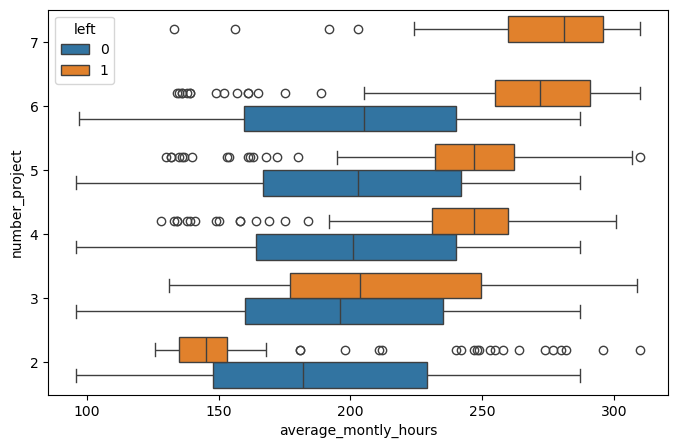

In [8]:
# # Create boxplot showing `average_monthly_hours` distributions for `number_project`, comparing employees who stayed versus those who left
fig, ax = plt.subplots(figsize = (8, 5))

sns.boxplot(data=df0, x='average_montly_hours', y='number_project', hue='left', orient="h")
ax.invert_yaxis()

*   Employees who left the company (orange) generally worked significantly more hours than those who stayed (blue), especially in the groups with 6 and 7 projects.
*   The group with 7 projects is particularly striking: all of them left the company, and their working hours were extremely high (approaching 300 hours/month).
*   Conversely, there is also a cluster of employees with only 2 projects who left; their working hours were lower than average, suggesting they might have felt stuck.

In [9]:
# Calculate mean and median satisfaction scores of employees who left and those who stayed
df0.groupby(['left'])['satisfaction_level'].median().reset_index()

,left,satisfaction_level
0,0,0.69
1,1,0.41


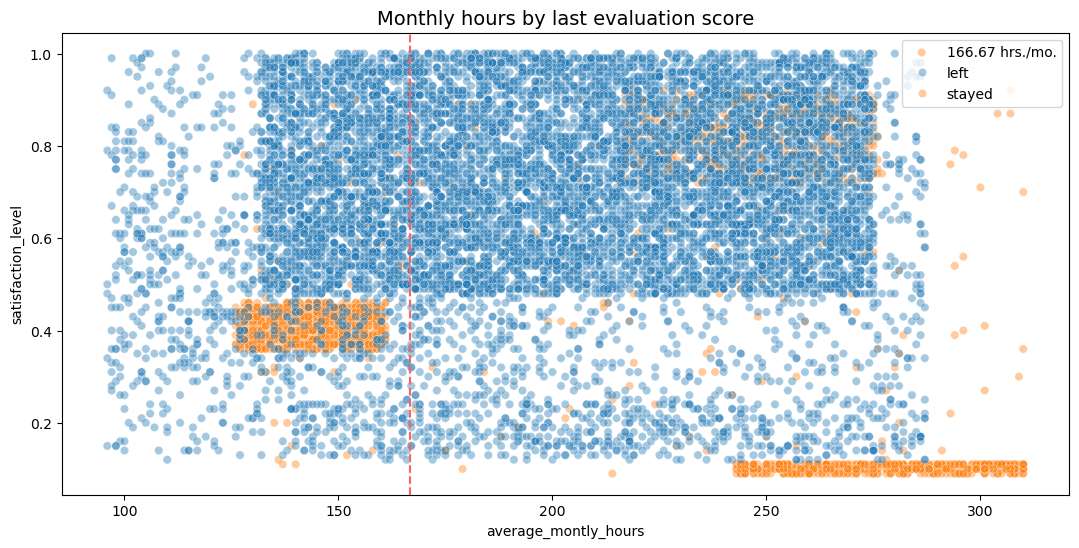

In [10]:
# Create scatterplot of `average_monthly_hours` versus `satisfaction_level`, comparing employees who stayed versus those who left
plt.figure(figsize=(13, 6))
sns.scatterplot(data=df0, x='average_montly_hours', y='satisfaction_level', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by last evaluation score', fontsize='14');

*   **The Burnout Cluster (Bottom Right):** A large group of employees who left worked extremely high hours (240–310 per month) with very low satisfaction scores (~0.1). These are likely "high-performers" who were pushed to their breaking point.
*   **The Stagnant Cluster (Middle Left):** Another group left while working moderate hours (~130–160) with satisfaction scores around 0.4. This suggests they might have felt underutilized or lacked career growth.

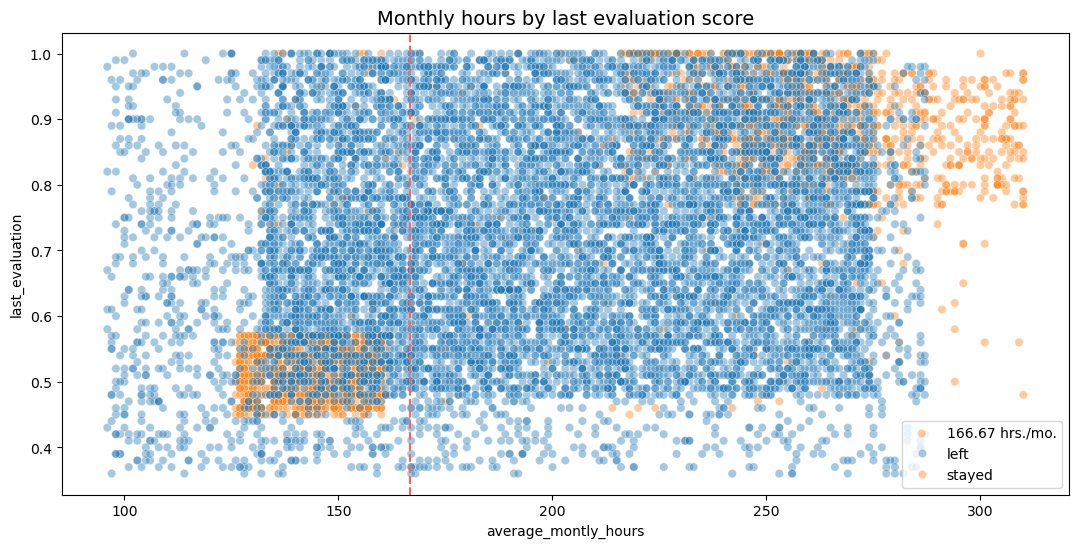

In [11]:
# Create scatterplot of `average_monthly_hours` vs `last_evaluation`

plt.figure(figsize=(13, 6))
sns.scatterplot(data=df0, x='average_montly_hours', y='last_evaluation', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by last evaluation score', fontsize='14');

The scatterplot indicates **two groups** of employees who left: 
- overworked employees who performed very well 
- employees who worked slightly under the nominal monthly average of 166.67 hours with lower evaluation scores.
  
Most of the employees in this company work over 167 hours per month.

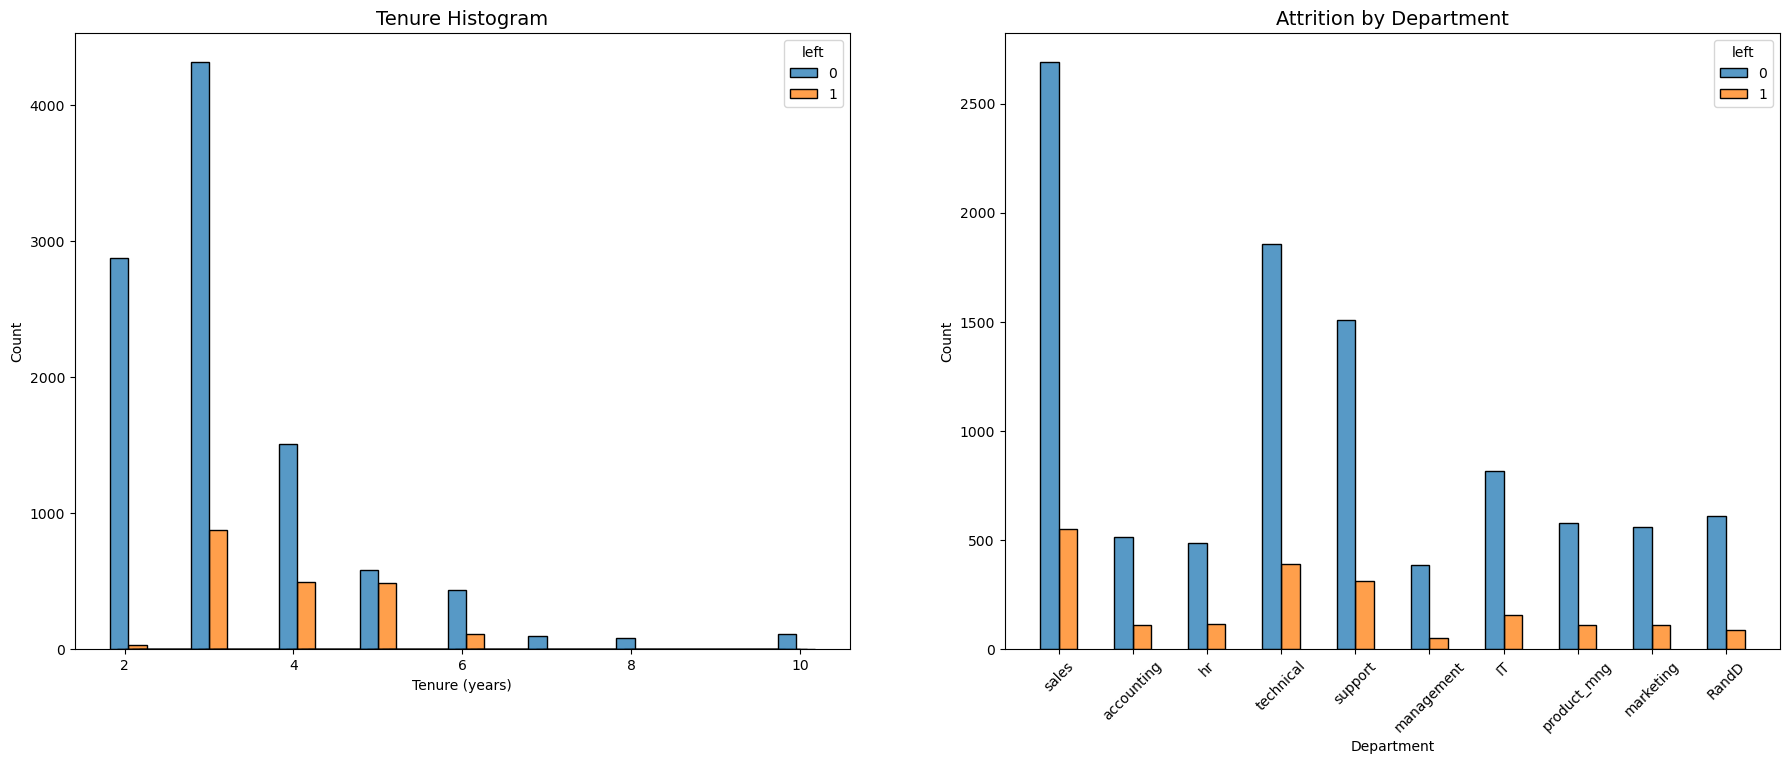

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(22, 8))

# Create histogram showing distribution of `tenure`, comparing employees who stayed versus those who left
sns.histplot(data=df0, x='time_spend_company', hue='left', multiple='dodge', shrink=5, ax=ax[0])
ax[0].set_title('Tenure Histogram', fontsize='14')
ax[0].set_xlabel('Tenure (years)')

# Create stacked histogram to compare department distribution of employees who left to that of employees who didn't
sns.histplot(data=df0, x='Department', hue='left', multiple='dodge', shrink=.5, ax=ax[1])
ax[1].set_title('Attrition by Department', fontsize='14')
plt.setp(ax[1].get_xticklabels(), rotation=45)

plt.show()

*   **Tenure:** There is a clear relationship between the length of service and attrition. Turnover peaks significantly at the **3-year mark** and remains high through year 5. Interestingly, employees who stay past 6 years are very unlikely to leave, suggesting that mid-tenure employees are at the highest risk of burnout or career dissatisfaction.
*   **Department:** Attrition appears to be distributed proportionally across all departments.

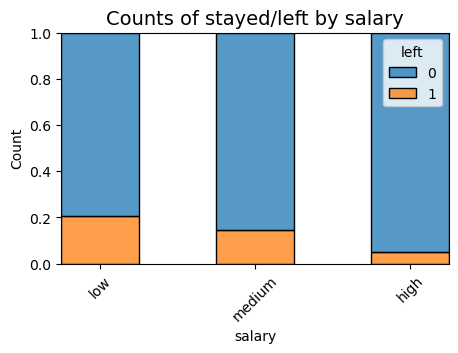

In [13]:
# Create normalized stacked histogram to compare the percentage of employees who left by salary.

plt.figure(figsize=(5,3))
sns.histplot(data=df0, x='salary', hue='left', multiple='fill', shrink=.5)
plt.xticks(rotation=45)
plt.title('Counts of stayed/left by salary', fontsize=14);

Employees with high salaries have a lower attrition rate.
There is a visible trend where the likelihood of leaving increases as salary decreases.

In [14]:
df0.groupby('promotion_last_5years')['left'].mean().reset_index()

,promotion_last_5years,left
0,0,0.168222
1,1,0.039409


Employees who were not promoted have an attrition rate of **16.8%**, employees who received a promotion have a significantly lower attrition rate of only **3.9%**.
A promotion reduces the probability of leaving by more than **4 times**.


In [15]:
df0.groupby('Work_accident')['left'].mean().reset_index()

,Work_accident,left
0,0,0.185978
1,1,0.056757


**18.6%** of employees without accidents left the company and only **5.7%** of employees who experienced a work accident left.
Interestingly, employees who had a work accident are less likely to leave. This may be due to administrative protections, compensation packages, or increased perceived job stability following an incident.

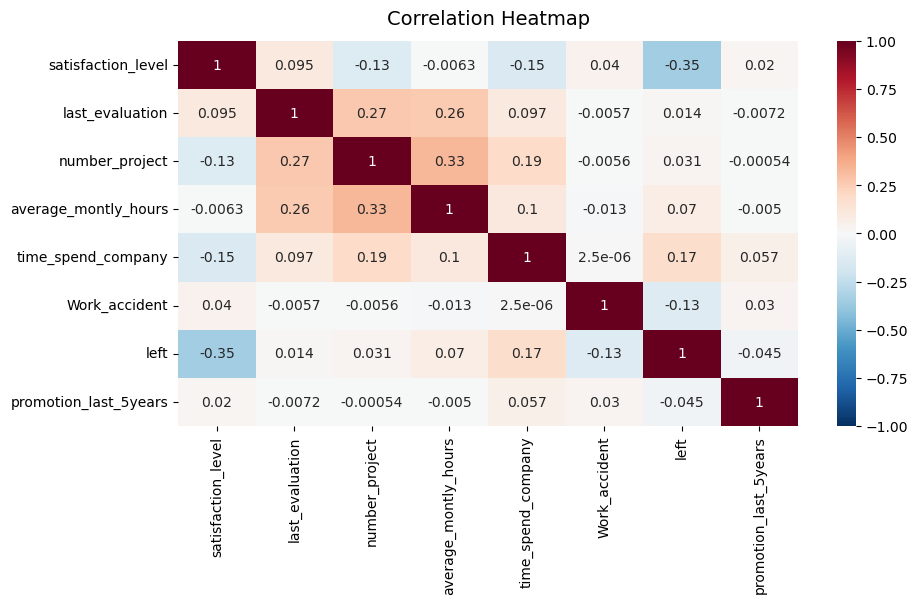

In [16]:
# Create a correlation heatmap

plt.figure(figsize=(10, 5))
heatmap = sns.heatmap(df0.corr(numeric_only=True), vmin=-1, vmax=1, annot=True, cmap=sns.color_palette("RdBu_r", as_cmap=True))
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':14}, pad=12);

The correlation heatmap confirms that the number of projects, monthly hours, and evaluation scores all have some positive correlation with each other, and whether an employee leaves is negatively correlated with their satisfaction level.

## Construct Stage
In this section, I construct the models and determine which models are most appropriate 

In [17]:
# Before splitting the data, encode the non-numeric variables, models require all input data to be numeric. 

# Encode the `salary` column as an ordinal numeric category
df = df0.copy()
df['salary'] = df['salary'].map({'low':1, 'medium':2, 'high':3})

In [18]:
# Dummy encode the `department` column
df = pd.get_dummies(df, columns = ['Department'], dtype=int)
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary,Department_IT,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical
0,0.38,0.53,2,157,3,0,1,0,1,0,0,0,0,0,0,0,1,0,0
1,0.80,0.86,5,262,6,0,1,0,2,0,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,1,0,2,0,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,1,0,1,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,1,0,1,0,0,0,0,0,0,0,1,0,0


In [19]:
# Target Variable Distribution
df['left'].value_counts(normalize = True).reset_index()

,left,proportion
0,0,0.833959
1,1,0.166041


The target variable `left` shows that approximately **83%** of employees stayed, while **17%** left the company. 
There is a class imbalance, but it is not severe enough to require extreme resampling techniques.

In [20]:
# Isolate Predictor Variables X and Target Variable

y = df['left']
X = df.drop('left', axis=1)

In [21]:
# # Split the data into training set and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y,
                                              test_size=0.2, random_state=42)

In [22]:
# Scale variables to constract Logistic Regression
cols_to_scale = ['satisfaction_level', 'last_evaluation', 'number_project', 
                 'average_montly_hours', 'time_spend_company']
scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

I used `StandardScaler` on continuous variables like hours and tenure, so features with large numbers do not overpower features with small numbers.

In [23]:
# Build a Logistic Regression

model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [24]:
# Get the coefficients of each variable
pd.Series(model.coef_[0], index=X.columns)

satisfaction_level       -0.923725
last_evaluation           0.123367
number_project           -0.313132
average_montly_hours      0.200327
time_spend_company        0.422839
Work_accident            -1.357442
promotion_last_5years    -1.101877
salary                   -0.620701
Department_IT            -0.033188
Department_RandD         -0.423546
Department_accounting     0.023445
Department_hr             0.076339
Department_management    -0.344740
Department_marketing     -0.020218
Department_product_mng   -0.112946
Department_sales          0.049927
Department_support        0.033027
Department_technical      0.057636
dtype: float64

Satisfaction level is the most important factor in this model

In [25]:
# Get the intercept of the model
model.intercept_

array([-0.8414026])

In [26]:
# Get the predicted probabilities of the training data
training_probabilities = model.predict_proba(X_train)
training_probabilities

array([[0.93185554, 0.06814446],
       [0.85010634, 0.14989366],
       [0.89356071, 0.10643929],
       ...,
       [0.97703713, 0.02296287],
       [0.89376355, 0.10623645],
       [0.92293405, 0.07706595]], shape=(9592, 2))

In [27]:
# 2. Create a new `logit` column in the `logit_data`

logit_data = X_train.copy()
logit_data['logit'] = [np.log(prob[1] / prob[0]) for prob in training_probabilities]
logit_data.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,salary,Department_IT,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,logit
2041,1.452599,1.142043,0.166626,0.804283,-0.281698,0,0,1,0,0,0,0,0,0,0,0,0,1,-2.615548
10444,0.000675,1.023353,-0.693124,0.783745,-0.281698,0,0,2,1,0,0,0,0,0,0,0,0,0,-1.735435
2030,0.913313,-0.756994,-0.693124,0.701594,-0.281698,0,0,1,0,0,0,0,0,0,0,0,1,0,-2.127639
11606,-0.289710,-1.943892,-0.693124,-1.947784,3.452472,0,0,3,0,0,0,0,1,0,0,0,0,0,-1.733760
2008,-0.538612,0.192524,1.886126,-1.516490,-0.281698,0,0,1,0,0,0,0,0,0,0,1,0,0,-1.904410


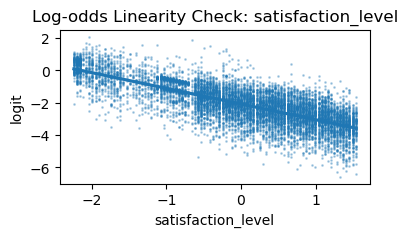

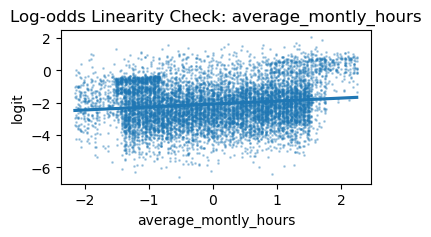

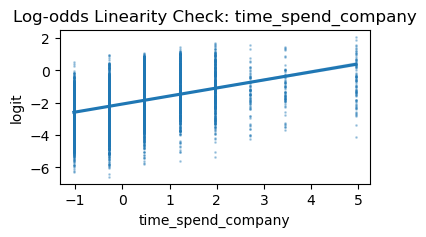

In [28]:
# Plot regplot of the most important variables' log-odds
cols_to_check = ['satisfaction_level', 'average_montly_hours', 'time_spend_company']

for col in cols_to_check:
    plt.figure(figsize=(4, 2))
    sns.regplot(x=col, y='logit', data=logit_data, scatter_kws={'s': 1, 'alpha': 0.3})
    plt.title(f'Log-odds Linearity Check: {col}')
    plt.show()

#### Assumption Check: Linearity
* The `regplot` shows that the relationship between key features and the log-odds (logit) is mostly linear.
* Since the points follow a straight line, the Logistic Regression model is mathematically valid for this data.

## Execute Stage
I will make predictions on the test data and evaluate results.

In [29]:
# Generate predictions metrics report on X_test
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.96      0.91      2001
           1       0.50      0.19      0.28       398

    accuracy                           0.83      2399
   macro avg       0.68      0.58      0.59      2399
weighted avg       0.80      0.83      0.80      2399



In [30]:
# Score the model (accuracy) on the test data
model.score(X_test, y_test)

0.8340975406419341

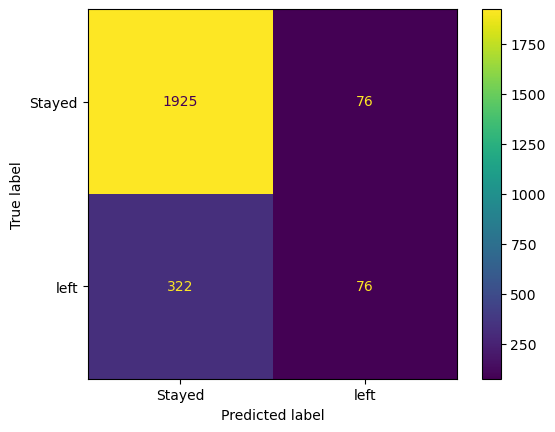

In [31]:
# Show results with a confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=['Stayed', 'left'],
                              ).plot()

#### Model Performance Evaluation
* **Accuracy (0.83):** Looks good, but it is misleading due to the class imbalance.
* **Recall (0.19):** This is very low. The model only identifies 19% of the employees who actually leave.
* **Conclusion:** Logistic Regression is not powerful enough to catch most of the "at-risk" employees. A more complex model like Random Forest is needed.

## Construct Stage. Advanced Modeling 
To improve the results, I will build a **Random Forest** model. I will use `GridSearchCV` to find the best settings (hyperparameters) and optimize for the **F1-score** to balance Precision and Recall.

In [32]:
# Separate into train, validate, test sets.
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size = 0.25, random_state = 0)

In [33]:
# Instantiate the random forest classifier
rf = RandomForestClassifier(random_state=42)

# Create a dictionary of hyperparameters to tune
cv_params = {'n_estimators' : [50,100,200], 
              'max_depth' : [10,20,50],        
              'min_samples_leaf' : [5,10,20], 
              'min_samples_split' : [0.001, 0.01],
              'max_features' : ["sqrt"], 
              'max_samples' : [0.5,0.8]}

# Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Instantiate the GridSearchCV object
rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='f1')

rf_cv.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [10, 20, ...], 'max_features': ['sqrt'], 'max_samples': [0.5, 0.8], 'min_samples_leaf': [5, 10, ...], ...}"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,None
,refit,'f1'
,cv,4
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [34]:
# Examine best score
rf_cv.best_score_

np.float64(0.9395844916609337)

In [35]:
# Examine best parameters
rf_cv.best_params_

{'max_depth': 20,
 'max_features': 'sqrt',
 'max_samples': 0.8,
 'min_samples_leaf': 5,
 'min_samples_split': 0.001,
 'n_estimators': 200}

* **Best CV Score:** The model achieved a score of **0.939** during cross-validation.
* **Optimal Parameters:** The best model uses **200 trees** with a maximum depth of **20**.
  
These settings provide a good balance between learning the data and being able to generalize to new employees.

## Execute Stage for advanced modeling
I will make predictions on the test data and evaluate results.

In [36]:
# Generate predictions metrics report on X_test
y_pred = rf_cv.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2001
           1       0.98      0.92      0.95       398

    accuracy                           0.98      2399
   macro avg       0.98      0.96      0.97      2399
weighted avg       0.98      0.98      0.98      2399



* **Precision (0.98):** When the model predicts an employee will leave, it is correct 98% of the time.
* **Recall (0.92):** The model successfully identifies 92% of all employees who actually left.
* **Conclusion:** This is a massive improvement compared to the Logistic Regression (which had a Recall of only 0.19). This model is highly reliable for business use.

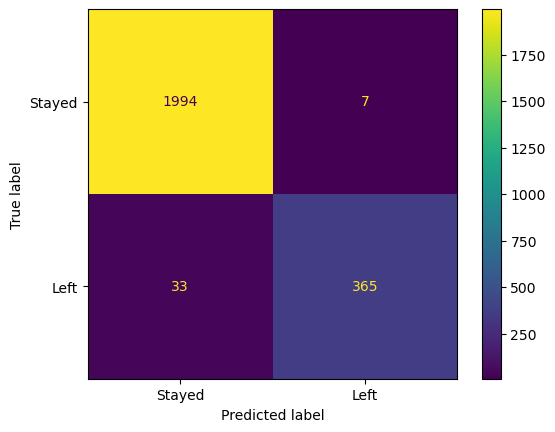

In [37]:
# Show results with a confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Left'])
disp.plot()

* **True Positives:** The model correctly caught **365 employees** who were planning to leave.
* **False Positives:** Only **7 employees** were wrongly predicted to leave.
* **Summary:** The model is very "clean" — it catches almost all departures with almost no false alarms.

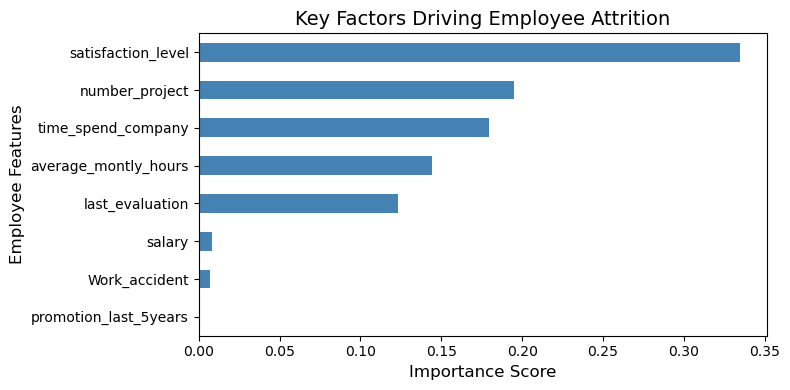

In [41]:
# 1. Get feature importances from the best model (the winner of GridSearch)
importances = rf_cv.best_estimator_.feature_importances_

# 2. Create a Series and map importances to the correct column names
rf_importances = pd.Series(importances, index=X_test.columns)

# 3. Filter the results: keep only features that do NOT contain the word 'Department'
rf_importances_filtered = rf_importances[~rf_importances.index.str.contains('Department')]

# 4. Sort values in ascending order for a proper horizontal bar chart
rf_importances_filtered = rf_importances_filtered.sort_values(ascending=True)

# 5. Create the visualization
plt.figure(figsize=(8, 4))
rf_importances_filtered.plot.barh(color='steelblue')

plt.title("Key Factors Driving Employee Attrition", fontsize=14)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Employee Features", fontsize=12)

plt.tight_layout()
plt.show()

This chart shows which factors "matter" most to the model:
1. **Satisfaction Level:** By far the most important predictor.
2. **Number of Projects & Tenure:** How long people stay and how much work they have are critical.
3. **Monthly Hours:** Workload is a key driver of burnout.

**Final Business Insight:** To keep employees, Salifort Motors must prioritize staff satisfaction and monitor the workload (hours and projects) for those who have been with the company for 3-5 years.

In [42]:
# Save the model
with open('salifort_rf_model.pickle', 'wb') as f:
    pickle.dump(rf_cv.best_estimator_, f)

print("Model saved successfully as 'salifort_rf_model.pickle'")

Model saved successfully as 'salifort_rf_model.pickle'


## Final Conclusion and Recommendations

### Model Summary
The final **Random Forest** model performed exceptionally well, achieving an **accuracy of 98%** and a **recall of 91%** on the test set. This means the model can correctly identify 9 out of 10 employees who are planning to leave, allowing the HR department to take action before they resign.

### Key Insights
1. **The Overwork Crisis:** Employees working more than **240–250 hours per month** and handling **6 or more projects** have a very high probability of leaving. This suggests a clear link between burnout and attrition.
2. **The "Tenure" Safety Zone:** Our analysis shows that the risk of leaving peaks between **3 and 5 years** of service. However, a crucial finding is that **employees who stay past 6 years are much less likely to leave**. Once an employee reaches this milestone, they typically become very loyal to the company.
3. **Satisfaction Gap:** Low satisfaction scores (~0.4 and below) are the strongest indicators of turnover. Salary is also a factor, but it often matters less than daily workload and career growth.

### Actionable Recommendations for Salifort Motors:
*   **Cap Project Load:** Limit the number of projects to a **maximum of 5 per person**. Our data shows that 7 projects almost guarantee a resignation.
*   **Monitor "Extreme" Overtime:** HR should flag any employee working more than **240 hours per month**. These individuals are at critical risk of burnout.
*   **Target the 3-5 Year Group:** Implement specific retention programs (like mid-career bonuses or role rotations) for employees in their 3rd to 5th year, as this is the highest risk period.
